# euclid_cutouts: Tutorial

[`euclid_cutouts`](https://github.com/margres/euclid_cutouts) is a small
pip-installable library for turning multi-band Euclid FITS cutouts (VIS,
NIR-Y, NIR-J, NIR-H, "IYJH") into colour RGB images. It wraps four
independent colour-rendering tools behind one API. It's the rendering half
of a larger repo that also fetches cutouts from Euclid MER tiles using
[Cutana](https://github.com/esa/Cutana) (ESA's cutout pipeline). See
`cutana_to_colour_tutorial.ipynb` in the same repo for that fetch step.
This notebook starts from FITS that already exist.

This notebook shows how to use the library to produce colour cutout images
from Euclid data. Four workflows are demonstrated:

1. **Single cutout**: render one (4, H, W) IYJH array through azulero, STCI
   and bulk_euclid
2. **FITS-input mode**: batch-render a directory of pre-made FITS cutout files
3. **ML-inference loop**: load FITS cutouts on the fly, run a classifier, and
   keep only the high-confidence detections (FITS + colour images)
4. **eummy example**: render the same 3 demo lenses through eummy, which
   works on the whole tile FITS mosaic rather than a cutout array

## The renderers

- **[azulero](https://kabasset.github.io/azulero/v2.0.0/index.html)**
  (Basset et al., CNES; [PyPI](https://pypi.org/project/azulero/)): LRGB
  composite from all 4 bands, asinh stretch, per-band sharpening,
  dead-pixel inpainting, hue/saturation mapping. Requires **v2.0+** (a
  near-total rewrite from 1.x, the API used here won't work on older
  versions).
- **STCI** (SpaceTelescopeColorImage, courtesy Tian Li;
  [PyPI](https://pypi.org/project/STCI/)): a PixInsight-like pipeline,
  background neutralisation, colour calibration, linked STF/histogram
  transform, luminosity replacement, SCNR, saturation.
- **[bulk-euclid-cutouts](https://github.com/mwalmsley/bulk-euclid-cutouts)**
  (Walmsley, M.): arcsinh and MTF (midtone-transfer-function) colour
  stretches, several VIS/Y/J band-combination variants. Not on PyPI,
  cloned locally (see Install below).
- **[eummy](https://github.com/schirmermischa/eummy)** (Schirmer, M.):
  contrast-based rendering with configurable black/white thresholds. Works
  differently from the other three: it's a CLI tool that processes a whole
  tile FITS mosaic at once (it does its own cutout extraction internally),
  not a per-object cutout array. See the eummy example under section 1
  below.

## Install

```bash
# from the repo root
pip install -e ".[renderers]"   # core + azulero + STCI
pip install eummy

# bulk_euclid isn't on PyPI, clone and point BULK_ROOT at it below
git clone https://github.com/mwalmsley/bulk-euclid-cutouts
pip install -e ./bulk-euclid-cutouts
```

## Assumptions

- **Network access to huggingface.co** for the Zoobot step (section 3).
  It downloads a checkpoint on first run, cached afterward.
- **`bulk_euclid` is a local clone, not on PyPI**. `BULK_ROOT` below
  defaults to this workspace's path; set the `BULK_EUCLID_ROOT`
  environment variable (or edit `BULK_ROOT` directly) if your clone
  lives elsewhere.
- **`azulero` >= 2.0 and any current `STCI`**. Both renderers' APIs are
  called directly (no version pin needed beyond `azulero>=2.0`; verified
  against `STCI` 0.1.1 and the latest 0.1.5 on PyPI as of 2026-09).
- **The eummy example needs real sky coordinates and the whole tile
  mosaic on disk**, not just a small FITS cutout with no WCS. It runs on
  this ESA Datalabs workspace's mounted Euclid tiles; adapt the tile
  lookup for a different data mount.


In [1]:
import os
import numpy as np
from astropy.io import fits
from PIL import Image

from euclid_cutouts import (
    load_fits_cutout,
    render_azulero,
    render_stci,
    render_bulk_variant,
    render_cutout,
    render_fits_dir,
)

# Path to a local bulk-euclid-cutouts clone (not on PyPI, see Install above).
# Defaults to a sibling dir; override for a different layout.
BULK_ROOT = os.environ.get("BULK_EUCLID_ROOT", "/media/user/bulk-euclid-cutouts")

## Loading a source list from a CSV

Everything above uses a hardcoded demo file. In practice you start from a
CSV of sources: at minimum an id, RA and Dec per row (matching the columns
`scripts/make_colour_cutouts.py`'s `SOURCES_CSV` expects; see the README's
"Input CSV columns" section for accepted column name aliases and optional
fields like `size_pixel`).

Below we write a small demo CSV from the same 3 lenses bundled in
`demo_fits/`, read it back with pandas, then match each source to its
nearest Euclid tile (needed for the eummy example further down, which
works on the whole tile mosaic rather than an already-cut FITS file).

If you already have FITS cutouts and only want colour images, skip straight
to section 2, "FITS-input mode".


In [2]:
import pandas as pd
from scipy.spatial import KDTree

demo_csv_path = "demo_sources.csv"
pd.DataFrame([
    {"id": "EUCL_J03473405-4944409", "ra": 56.891875, "dec": -49.734444},
    {"id": "EUCL_J03515662-5051113", "ra": 57.985917, "dec": -50.850306},
    {"id": "EUCL_J04181006-4918310", "ra": 64.541917, "dec": -49.300861},
]).to_csv(demo_csv_path, index=False)

sources_df = pd.read_csv(demo_csv_path)
sources_df


,id,ra,dec
0,EUCL_J03473405-4944409,56.891875,-49.734444
1,EUCL_J03515662-5051113,57.985917,-50.850306
2,EUCL_J04181006-4918310,64.541917,-49.300861


In [3]:
tiles = pd.read_csv("tile_centres.csv")


def to_xyz(ra_deg, dec_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    return np.column_stack([np.cos(dec) * np.cos(ra),
                            np.cos(dec) * np.sin(ra),
                            np.sin(dec)])


tree = KDTree(to_xyz(tiles["ra"].values, tiles["dec"].values))
_, idx = tree.query(to_xyz(sources_df["ra"].values, sources_df["dec"].values))
matched = tiles.iloc[idx].reset_index(drop=True)
sources_df["tile_index"] = matched["tile_index"].values
sources_df["release_dir"] = matched["release_dir"].values
sources_df


,id,ra,dec,tile_index,release_dir
0,EUCL_J03473405-4944409,56.891875,-49.734444,101278603,/media/home/data/euclid_idr1/DR1/R1
1,EUCL_J03515662-5051113,57.985917,-50.850306,101274909,/media/home/data/euclid_idr1/DR1/R1
2,EUCL_J04181006-4918310,64.541917,-49.300861,101280500,/media/home/data/euclid_idr1/DR1/R1


## 1. Render a single cutout

`render_cutout` takes a `(4, H, W)` IYJH float32 array (band order: VIS,
NIR-Y, NIR-J, NIR-H) and returns a dict of `{name: (H, W, 3) uint8 RGB}`
arrays — one per enabled renderer/variant.

Here we load a real grade-A strong-lens candidate from Q1 from the
`demo_fits/` directory.

Loaded EUCL_J03473405-4944409.fits  shape=(4, 101, 101)


All 8 renderers/variants: ['azulero', 'stci', 'gz_arcsinh_vis_y', 'gz_arcsinh_vis_only', 'gz_arcsinh_triple', 'sw_mtf_vis_only', 'sw_mtf_vis_y', 'sw_mtf_vis_y_j']


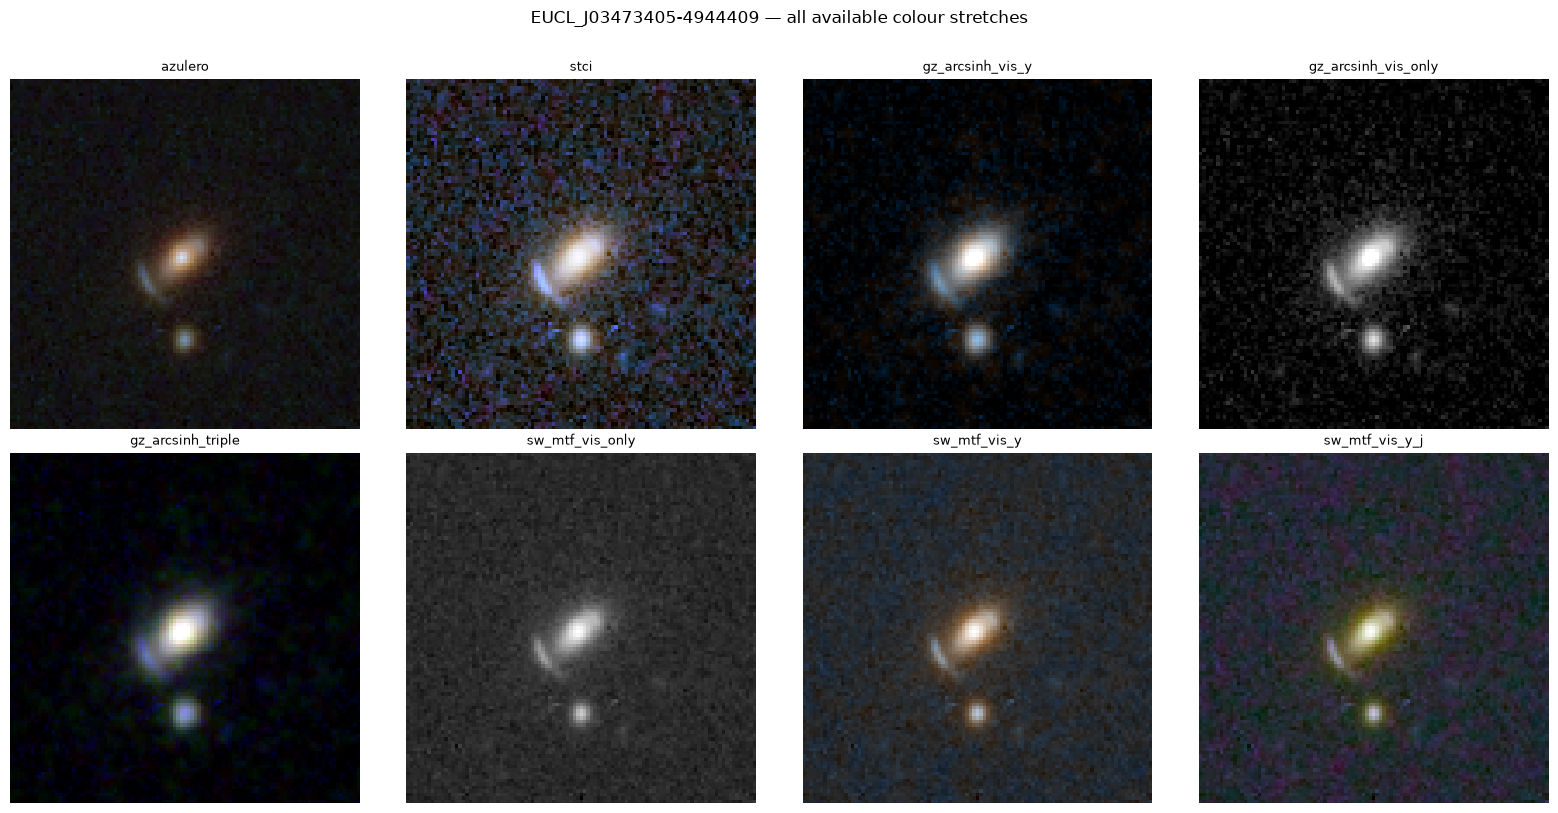

In [4]:
DEMO_DIR = os.path.join(os.path.dirname(os.getcwd()), "demo_fits")
if not os.path.isdir(DEMO_DIR):
    DEMO_DIR = "demo_fits"

# Pick the first FITS file in the demo directory
demo_files = sorted(f for f in os.listdir(DEMO_DIR) if f.endswith(".fits"))
lens_path = os.path.join(DEMO_DIR, demo_files[0])
iyjh = load_fits_cutout(lens_path, band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])
print(f"Loaded {demo_files[0]}  shape={iyjh.shape}")

# Render through ALL available colour stretches
ALL_BULK_VARIANTS = [
    "gz_arcsinh_vis_y",     # VIS+Y composite (arcsinh)
    "gz_arcsinh_vis_only",  # VIS-only (arcsinh)
    "gz_arcsinh_triple",    # VIS+Y+J three-band (arcsinh)
    "sw_mtf_vis_only",      # VIS-only (midtone transfer)
    "sw_mtf_vis_y",         # VIS+Y (midtone transfer + LAB luminosity)
    "sw_mtf_vis_y_j",       # VIS+Y+J (midtone transfer + LAB luminosity)
]

results = render_cutout(
    iyjh,
    renderers=["azulero", "stci", "bulk_euclid"],
    bulk_variants=ALL_BULK_VARIANTS,
    bulk_euclid_root=BULK_ROOT,
)

print(f"All {len(results)} renderers/variants:", list(results.keys()))

import matplotlib.pyplot as plt
n = len(results)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))
axes = axes.flatten()
for ax, (name, rgb) in zip(axes, results.items()):
    ax.imshow(rgb, origin="upper")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle(f"{demo_files[0].replace('.fits','')} — all available colour stretches", y=1.01)
plt.tight_layout()
plt.show()

### Using a single renderer

You don't have to run all colour stretches — just pass the one you want.
`render_azulero` and `render_bulk_variant` work on individual cutouts:

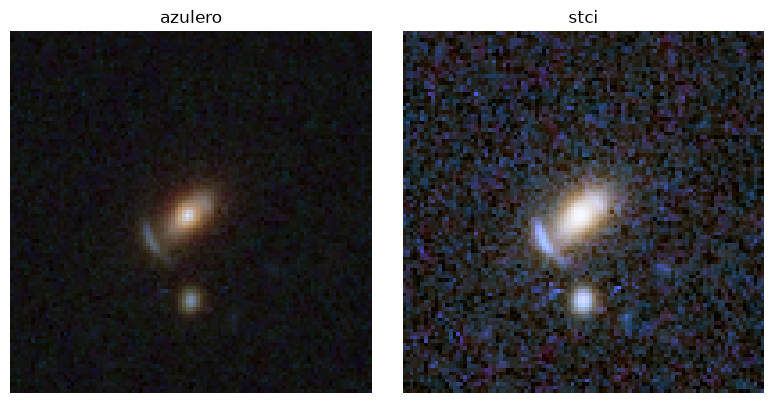

Keys: ['stci']


In [5]:
# Azulero only
rgb_azulero = render_azulero(iyjh)

# STCI only
rgb_stci = render_stci(iyjh)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rgb_azulero); axes[0].set_title("azulero"); axes[0].axis("off")
axes[1].imshow(rgb_stci);    axes[1].set_title("stci"); axes[1].axis("off")
plt.tight_layout()
plt.show()

# render_cutout also accepts a single renderer:
out = render_cutout(iyjh, renderers=["stci"])
print("Keys:", list(out.keys()))  # only stci

## 2. Batch-render a directory of FITS cutouts

`render_fits_dir` batch-processes a folder of FITS cutout files. Here we use
`demo_fits/` which contains 3 real grade-A Q1 lens candidates (randomly
selected from the reference lens sample).

In [6]:
# demo_fits/ already contains 3 real Q1 lens cutouts (4-band IYJH)
print("Input FITS files:")
for fn in sorted(os.listdir(DEMO_DIR)):
    if fn.endswith(".fits"):
        print(f"  {fn}")

Input FITS files:
  EUCL_J03473405-4944409.fits
  EUCL_J03515662-5051113.fits
  EUCL_J04181006-4918310.fits


In [7]:
import shutil

demo_out_dir = "demo_output"
shutil.rmtree(demo_out_dir, ignore_errors=True)

totals = render_fits_dir(
    input_dir=DEMO_DIR,
    output_dir=demo_out_dir,
    enable_azulero=True,
    enable_stci=True,
    enable_bulk_euclid=True,
    bulk_variants=["gz_arcsinh_vis_y"],
    band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"],
    fmt="jpg",
    jpeg_quality=95,
    n_workers=1,
    progress_bar=True,
    bulk_euclid_root=BULK_ROOT,
)

print("\nTotals:", totals)
print("\nOutput tree:")
for root, dirs, files in os.walk(demo_out_dir):
    level = root.replace(demo_out_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s]

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s, azulero=1  gz_arcsinh_vis_y=1  stci=1]

Rendering FITS cutouts:   0%|          | 0/3 [00:00<?, ?file/s, azulero=2  gz_arcsinh_vis_y=2  stci=2]

Rendering FITS cutouts:  67%|██████▋   | 2/3 [00:00<00:00,  7.58file/s, azulero=2  gz_arcsinh_vis_y=2  stci=2]

Rendering FITS cutouts:  67%|██████▋   | 2/3 [00:00<00:00,  7.58file/s, azulero=3  gz_arcsinh_vis_y=3  stci=3]

Rendering FITS cutouts: 100%|██████████| 3/3 [00:00<00:00, 10.40file/s, azulero=3  gz_arcsinh_vis_y=3  stci=3]


Totals: {'azulero': 3, 'stci': 3, 'gz_arcsinh_vis_y': 3}

Output tree:
demo_output/
  azulero/
    EUCL/
      EUCL_J03473405-4944409.jpg
      EUCL_J03515662-5051113.jpg
      EUCL_J04181006-4918310.jpg
  stci/
    EUCL/
      EUCL_J03473405-4944409.jpg
      EUCL_J03515662-5051113.jpg
      EUCL_J04181006-4918310.jpg
  gz_arcsinh_vis_y/
    EUCL/
      EUCL_J03473405-4944409.jpg
      EUCL_J03515662-5051113.jpg
      EUCL_J04181006-4918310.jpg


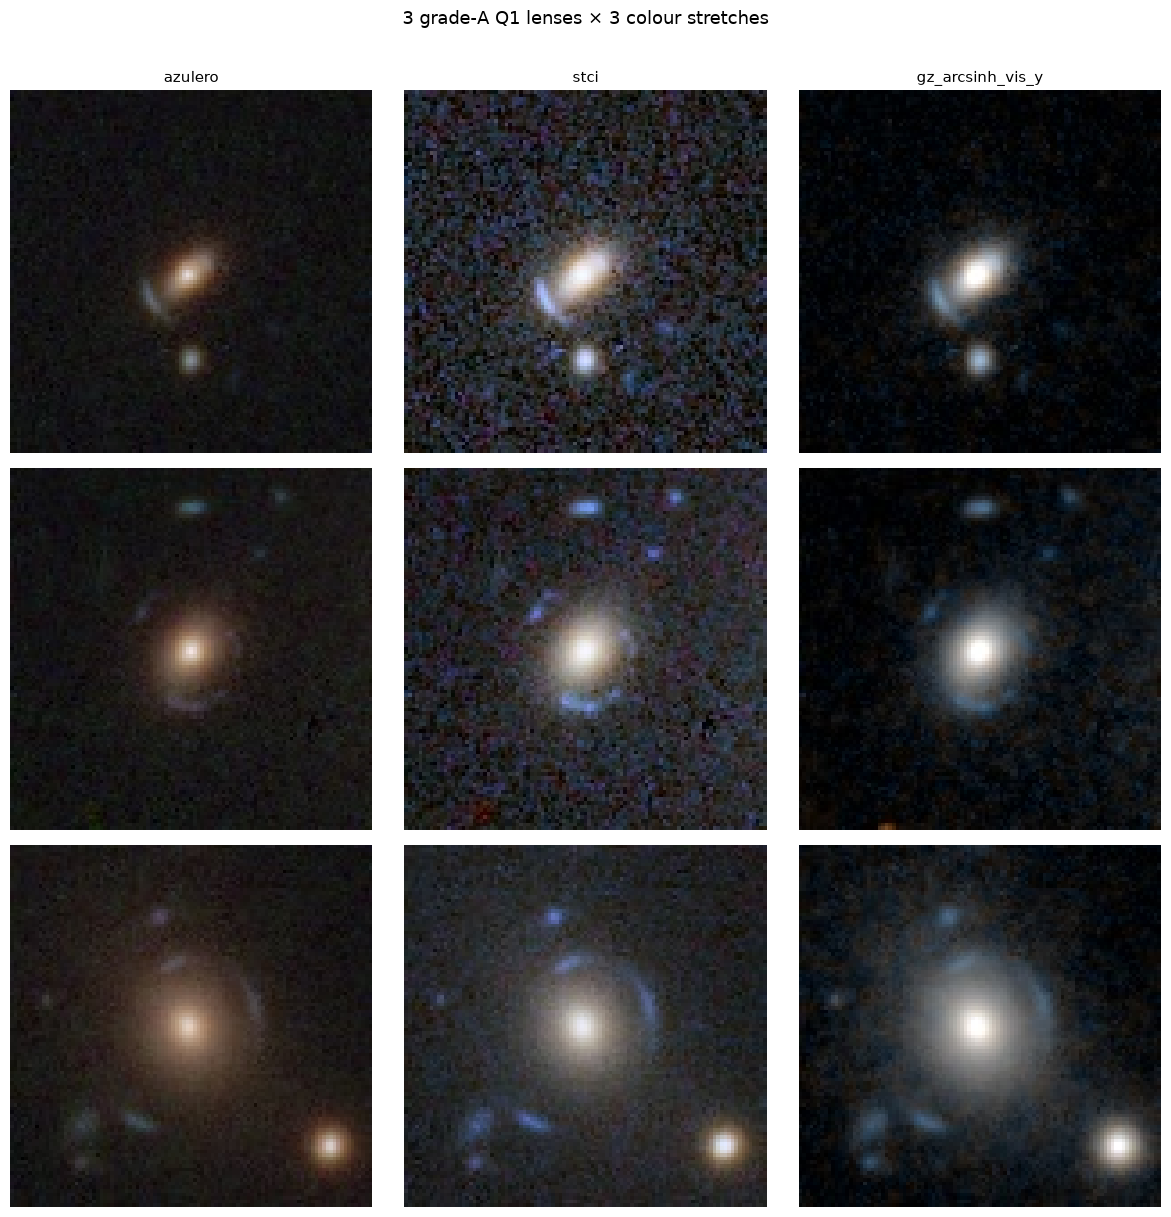

In [8]:
# Display all 3 lenses x 3 renderers
# (renderers write to {pipeline}/{tile_id}/{source_id}.jpg — glob to find each file)
import glob
variants = ["azulero", "stci", "gz_arcsinh_vis_y"]
stems = sorted(os.path.splitext(f)[0] for f in os.listdir(DEMO_DIR) if f.endswith(".fits"))

fig, axes = plt.subplots(len(stems), len(variants),
                         figsize=(4 * len(variants), 4 * len(stems)))
for row, stem in enumerate(stems):
    for col, var in enumerate(variants):
        matches = glob.glob(os.path.join(demo_out_dir, var, "**", f"{stem}.jpg"), recursive=True)
        img_path = matches[0]  # renderers write to {pipeline}/{tile_id}/{source_id}.jpg
        axes[row, col].imshow(Image.open(img_path))
        if row == 0:
            axes[row, col].set_title(var, fontsize=11)
        if col == 0:
            axes[row, col].set_ylabel(stem.replace("_lens", ""), fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("3 grade-A Q1 lenses × 3 colour stretches", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### About `band_order`

Multi-extension FITS cutout files store each band as a separate HDU
(CHANNEL_1, CHANNEL_2, ...), but different tools write the bands in different
orders. `band_order` tells the loader which band each extension corresponds to:

```
CHANNEL_1 → band_order[0]
CHANNEL_2 → band_order[1]
...
```

The loader maps each band to its slot in the internal (4, H, W) IYJH array:
VIS → index 0, NIR_Y → 1, NIR_J → 2, NIR_H → 3. Bands not present in the
FITS file are zero-filled.

| Source of FITS cutouts | `band_order` to use |
|---|---|
| This pipeline's `demo_fits/` | `["VIS", "NIR_Y", "NIR_J", "NIR_H"]` (default) |
| Cutana 3-band (workspace convention) | `["NIR_Y", "NIR_J", "VIS"]` |
| Single-band VIS-only | `["VIS"]` |

```python
# Cutana 3-band example
totals = render_fits_dir(
    input_dir="/path/to/cutana_output",
    output_dir="cutouts",
    band_order=["NIR_Y", "NIR_J", "VIS"],
    enable_azulero=True,
)
```

## 3. CSV-mode (tile-based pipeline via CLI)

The original tile-based pipeline reads a CSV of sources, resolves tiles via
HEALPix, loads full tile FITS, extracts cutouts, and renders through all four
colour stretches (azulero, eummy, bulk_euclid). This mode also supports eummy,
which needs tile-level FITS on disk.

Run from the terminal:

```bash
# Edit the CONFIG block at the top of the script first, then:
python scripts/make_colour_cutouts.py
```

Or switch to FITS-input mode from the same script by setting
`INPUT_FITS_DIR` in the CONFIG block — the script then calls `render_fits_dir`
internally.

## 4. ML-inference loop with Zoobot Euclid

Here we use [Zoobot Euclid](https://huggingface.co/mwalmsley/zoobot-encoder-euclid)
(Walmsley+25), a ConvNeXt encoder pretrained on Euclid morphology data. It
produces a 640-dim feature vector for each cutout.

The workflow:
1. Load each FITS cutout → render to RGB → resize to 224×224
2. Run Zoobot encoder → get 640-dim feature embedding
3. Use the feature-norm as a proxy "interestingness" score (in real use you'd
   train a classification head or use a downstream classifier)
4. Only keep cutouts above a threshold — save the FITS + colour images

**Assumes:** `pip install torch timm` (no separate `zoobot` package needed —
the encoder is loaded via `timm`'s HuggingFace Hub integration), and
**outbound network access to huggingface.co** to download the ~350MB
checkpoint on first run (works unauthenticated; set `HF_TOKEN` to avoid
rate limits). Cached under `~/.cache/huggingface/` after the first load.

In [9]:
def ml_filter_and_render(
    fits_dir, output_dir, predict_fn, *,
    threshold=0.5, band_order=None, renderers=None, bulk_variants=None,
    fmt="jpg", jpeg_quality=95, save_fits=True,
    bulk_euclid_root=None,
):
    """Load FITS cutouts, run predict_fn(iyjh)->score, keep above threshold."""
    import glob as _g
    if renderers is None:
        renderers = ["azulero", "stci"]
    if bulk_variants is None:
        bulk_variants = ["gz_arcsinh_vis_y"]
    if band_order is None:
        band_order = ["VIS", "NIR_Y", "NIR_J", "NIR_H"]

    fits_files = sorted(_g.glob(os.path.join(fits_dir, "*.fits")))
    print(f"Scanning {len(fits_files)} FITS files, threshold={threshold:.4f}")

    fits_out = os.path.join(output_dir, "fits")
    if save_fits:
        os.makedirs(fits_out, exist_ok=True)
    colour_dirs = {}
    if "azulero" in renderers:
        d = os.path.join(output_dir, "azulero")
        os.makedirs(d, exist_ok=True)
        colour_dirs["azulero"] = d
    if "stci" in renderers:
        d = os.path.join(output_dir, "stci")
        os.makedirs(d, exist_ok=True)
        colour_dirs["stci"] = d
    if "bulk_euclid" in renderers:
        for v in bulk_variants:
            d = os.path.join(output_dir, v)
            os.makedirs(d, exist_ok=True)
            colour_dirs[v] = d

    save_kw = {"quality": jpeg_quality} if fmt == "jpg" else {}
    results, n_kept = [], 0

    for fp in fits_files:
        stem = os.path.splitext(os.path.basename(fp))[0]
        iyjh_local = load_fits_cutout(fp, band_order=band_order)
        if iyjh_local is None:
            results.append({"stem": stem, "fits_path": fp, "probability": 0.0, "kept": False})
            continue
        prob = float(predict_fn(iyjh_local))
        kept = prob >= threshold
        results.append({"stem": stem, "fits_path": fp, "probability": prob, "kept": kept})
        if not kept:
            continue
        if save_fits:
            shutil.copy2(fp, os.path.join(fits_out, f"{stem}.fits"))
        colour_results = render_cutout(
            iyjh_local, renderers=renderers, bulk_variants=bulk_variants,
            bulk_euclid_root=bulk_euclid_root)
        for name, rgb in colour_results.items():
            Image.fromarray(rgb).save(os.path.join(colour_dirs[name], f"{stem}.{fmt}"), **save_kw)
        n_kept += 1

    print(f"Done: {n_kept}/{len(fits_files)} kept (threshold={threshold:.4f})")
    return results

In [10]:
import torch
import timm

# Load Zoobot Euclid encoder from HuggingFace
zoobot_model = timm.create_model(
    "hf_hub:mwalmsley/zoobot-encoder-euclid",
    pretrained=True,
    num_classes=0,  # encoder only — no classification head
)
zoobot_model.eval()
print(f"Zoobot encoder loaded: {type(zoobot_model).__name__}, "
      f"output features: {zoobot_model.num_features}")

Zoobot encoder loaded: ConvNeXt, output features: 640


In [11]:
def zoobot_predict(iyjh):
    """Render cutout to RGB, resize to 224x224, run Zoobot, return feature norm."""
    rgb = render_bulk_variant("gz_arcsinh_vis_y",
                              iyjh[0], iyjh[1], iyjh[2],
                              bulk_euclid_root=BULK_ROOT)
    if rgb is None:
        return 0.0
    img = Image.fromarray(rgb).resize((224, 224), Image.LANCZOS)
    x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    x = x.unsqueeze(0)
    with torch.no_grad():
        features = zoobot_model(x)
    return features.norm().item()

# Test on one lens
test_iyjh = load_fits_cutout(lens_path, band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])
score = zoobot_predict(test_iyjh)
print(f"Test score for {demo_files[0]}: {score:.4f}")

Test score for EUCL_J03473405-4944409.fits: 15.2579


In [12]:
# Run Zoobot on all 3 lenses and extract features + scores
import glob as _glob

fits_files = sorted(_glob.glob(os.path.join(DEMO_DIR, "*.fits")))
all_features = {}
all_scores = {}

for fp in fits_files:
    stem = os.path.splitext(os.path.basename(fp))[0]
    iyjh_i = load_fits_cutout(fp, band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])

    # Get features
    rgb = render_bulk_variant("gz_arcsinh_vis_y",
                              iyjh_i[0], iyjh_i[1], iyjh_i[2],
                              bulk_euclid_root=BULK_ROOT)
    img = Image.fromarray(rgb).resize((224, 224), Image.LANCZOS)
    x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0

    with torch.no_grad():
        feats = zoobot_model(x.unsqueeze(0)).squeeze()

    all_features[stem] = feats.numpy()
    all_scores[stem] = feats.norm().item()
    print(f"  {stem}: feature norm = {all_scores[stem]:.4f}, "
          f"feature shape = {feats.shape}")

print(f"\nScores: { {k: f'{v:.4f}' for k, v in all_scores.items()} }")

  EUCL_J03473405-4944409: feature norm = 15.2579, feature shape = torch.Size([640])


  EUCL_J03515662-5051113: feature norm = 17.8739, feature shape = torch.Size([640])


  EUCL_J04181006-4918310: feature norm = 19.9151, feature shape = torch.Size([640])

Scores: {'EUCL_J03473405-4944409': '15.2579', 'EUCL_J03515662-5051113': '17.8739', 'EUCL_J04181006-4918310': '19.9151'}


In [13]:
# Use the scores to filter: keep only above median score
scores_arr = np.array(list(all_scores.values()))
threshold = float(np.median(scores_arr))
print(f"Threshold (median feature norm): {threshold:.4f}\n")

ml_out_dir = "demo_ml_output"
shutil.rmtree(ml_out_dir, ignore_errors=True)

results = ml_filter_and_render(
    fits_dir=DEMO_DIR,
    output_dir=ml_out_dir,
    predict_fn=zoobot_predict,
    threshold=threshold,
    renderers=["azulero", "stci"],
)

Threshold (median feature norm): 17.8739

Scanning 3 FITS files, threshold=17.8739


Done: 2/3 kept (threshold=17.8739)


In [14]:
# --- Inspect results ---
import pandas as pd

df_results = pd.DataFrame(results)
df_results["probability"] = df_results["probability"].round(4)
print(df_results[["stem", "probability", "kept"]].to_string(index=False))

print(f"\nKept cutouts saved to: {ml_out_dir}")
for sub in ["fits", "azulero", "stci"]:
    d = os.path.join(ml_out_dir, sub)
    if os.path.isdir(d):
        print(f"  {sub}/: {os.listdir(d)}")

                  stem  probability  kept
EUCL_J03473405-4944409      15.2579 False
EUCL_J03515662-5051113      17.8739  True
EUCL_J04181006-4918310      19.9151  True

Kept cutouts saved to: demo_ml_output
  fits/: ['EUCL_J03515662-5051113.fits', 'EUCL_J04181006-4918310.fits']
  azulero/: ['EUCL_J03515662-5051113.jpg', 'EUCL_J04181006-4918310.jpg']
  stci/: ['EUCL_J03515662-5051113.jpg', 'EUCL_J04181006-4918310.jpg']


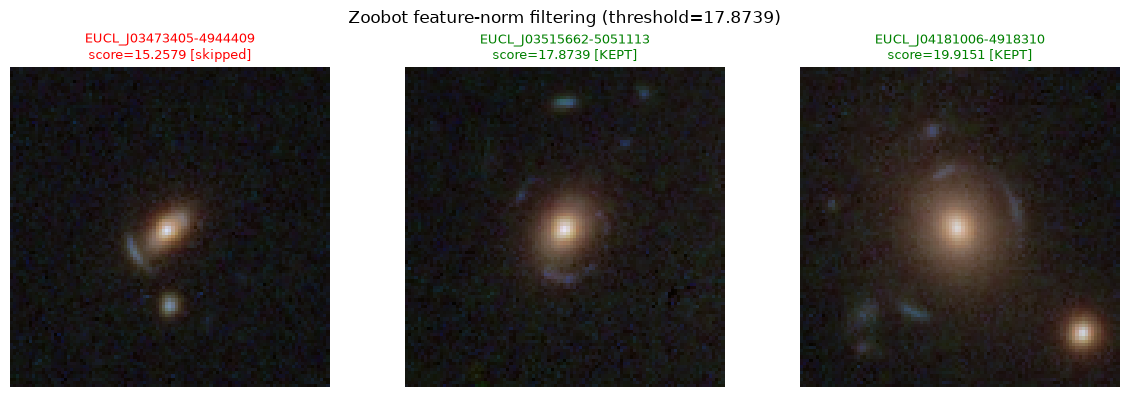

In [15]:
# --- Display kept vs rejected ---
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4),
                         squeeze=False)
for ax, r in zip(axes[0], results):
    # Load the rendered image (use azulero from batch output or render on the fly)
    iyjh_i = load_fits_cutout(r["fits_path"], band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])
    rgb = render_azulero(iyjh_i)
    ax.imshow(rgb)
    status = "KEPT" if r["kept"] else "skipped"
    ax.set_title(f"{r['stem'].replace('_lens','')}\nscore={r['probability']:.4f} [{status}]",
                 fontsize=9, color="green" if r["kept"] else "red")
    ax.axis("off")
plt.suptitle(f"Zoobot feature-norm filtering (threshold={threshold:.4f})")
plt.tight_layout()
plt.show()

## 5. eummy example (needs the whole tile FITS)

eummy is a fourth colour renderer used across this repo, but it works
differently from azulero, STCI and bulk_euclid above: it's a CLI tool that
processes a whole tile FITS mosaic at once and does its own cutout
extraction from RA/Dec internally, rather than taking a pre-cut cutout
array. So it can't go through `render_cutout`. Instead we point it at the
tile's IYJH mosaic files plus a small RA/Dec catalog, reusing the same
helpers `scripts/make_colour_cutouts.py`'s CSV pipeline uses
(`run_eummy_tile`, which sets up a small tile workspace, writes the
catalog, runs the `eummy` CLI, then matches its output back to sources by
RA/Dec).

This needs each source's tile resolved (`sources_df`, built earlier under
"Loading a source list from a CSV"), so it only works for sources with
known sky positions, not an arbitrary already-cut FITS file with no WCS.
Each call processes one whole tile mosaic, so it's slower per source than
the other three renderers. Note eummy needs **absolute** paths for
`--path`; a relative path makes it double up the path internally and fail.


EUCL_J03473405-4944409: 1 eummy PNG(s) written


EUCL_J03515662-5051113: 1 eummy PNG(s) written


EUCL_J04181006-4918310: 1 eummy PNG(s) written


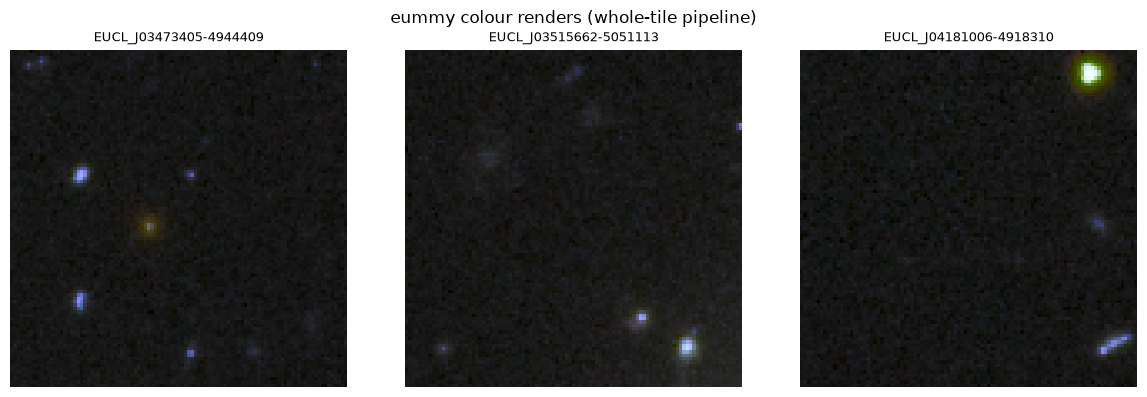

In [16]:
import sys
sys.path.insert(0, "scripts")
import make_colour_cutouts as mcc
from fits_path_utils import find_fits_paths

EUMMY_BAND_TO_INST = {"VIS": "VIS", "NIR_Y": "NISP", "NIR_J": "NISP", "NIR_H": "NISP"}
EUMMY_BANDS = ["VIS", "NIR_Y", "NIR_J", "NIR_H"]

eummy_out_dir = os.path.abspath("demo_output/eummy")
os.makedirs(eummy_out_dir, exist_ok=True)

for row in sources_df.itertuples():
    iyjh_paths = find_fits_paths(int(row.tile_index), EUMMY_BANDS, row.release_dir,
                                 EUMMY_BAND_TO_INST, ra=row.ra, dec=row.dec)
    tile_dir = os.path.abspath(os.path.join("demo_output", f"_eummy_tile_{row.tile_index}"))
    src = {"id": row.id, "ra": row.ra, "dec": row.dec, "size_pixel": 101}
    n = mcc.run_eummy_tile(iyjh_paths, [src], tile_dir, eummy_out_dir)
    print(f"{row.id}: {n} eummy PNG(s) written")

fig, axes = plt.subplots(1, len(sources_df), figsize=(4 * len(sources_df), 4))
for ax, row in zip(axes, sources_df.itertuples()):
    ax.imshow(Image.open(os.path.join(eummy_out_dir, f"{row.id}.png")))
    ax.set_title(row.id, fontsize=9)
    ax.axis("off")
plt.suptitle("eummy colour renders (whole-tile pipeline)")
plt.tight_layout()
plt.show()


## API summary

| Function | Input | Output | Use case |
|---|---|---|---|
| `load_fits_cutout(path, band_order)` | FITS file path | `(4, H, W)` float32 or None | Load any multi-extension FITS cutout |
| `render_azulero(iyjh)` | `(4, H, W)` float32 | `(H, W, 3)` uint8 RGB | Single azulero colour image |
| `render_stci(iyjh)` | `(4, H, W)` float32 | `(H, W, 3)` uint8 RGB | Single STCI colour image |
| `render_bulk_variant(variant, vis, y, j)` | per-band 2D arrays | `(H, W, 3)` uint8 RGB | Single bulk_euclid variant |
| `render_cutout(iyjh, renderers, ...)` | `(4, H, W)` float32 | `{name: RGB}` dict | Multi-renderer in one call |
| `render_fits_dir(input_dir, output_dir, ...)` | directory of FITS | `{name: count}` dict | Batch rendering with multiprocessing |

In [17]:
# --- Cleanup demo output ---
shutil.rmtree(demo_out_dir, ignore_errors=True)
shutil.rmtree(ml_out_dir, ignore_errors=True)
print("Cleaned up output dirs. demo_fits/ kept for re-runs.")

Cleaned up output dirs. demo_fits/ kept for re-runs.
